In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving content1.jfif to content1.jfif


In [3]:
from google.colab import files

uploaded = files.upload()

Saving style1.jfif to style1.jfif


In [4]:
def load_image(img_path, max_size=400):
    image = Image.open(img_path).convert('RGB')

    size = max(max(image.size), max_size)

    transform = transforms.Compose([
        transforms.Resize((max_size, max_size)),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0)
    return image

content = load_image("content1.jfif")
style = load_image("style1.jfif")

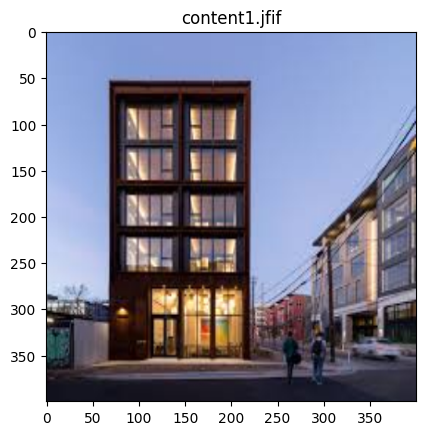

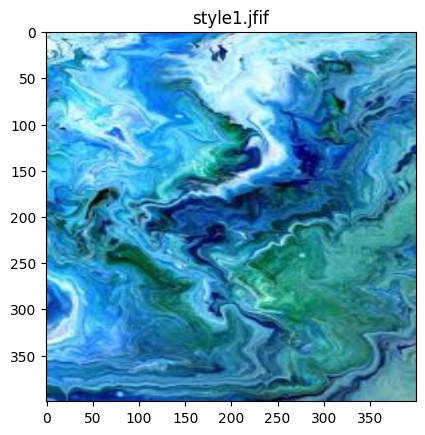

In [5]:
def imshow(tensor, title=None):
    image = tensor.clone().detach().squeeze(0)
    image = image.permute(1,2,0)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.show()

imshow(content, "content1.jfif")
imshow(style, "style1.jfif")

In [6]:
vgg = models.vgg19(pretrained=True).features
for param in vgg.parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 79.7MB/s]


In [7]:
def get_features(image, model):
    layers = {
        '0': 'conv1',
        '5': 'conv2',
        '10': 'conv3',
        '19': 'conv4',
        '28': 'conv5'
    }

    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x

    return features

In [8]:
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

target = content.clone().requires_grad_(True)

optimizer = optim.Adam([target], lr=0.003)

for step in range(200):
    target_features = get_features(target, vgg)

    style_loss = 0
    content_loss = 0

    for layer in content_features:
        content_loss += torch.mean((target_features[layer] - content_features[layer])**2)

    for layer in style_features:
        style_loss += torch.mean((target_features[layer] - style_features[layer])**2)

    loss = content_loss + 1e6 * style_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print("Step:", step, "Loss:", loss.item())

Step: 0 Loss: 9585054.0
Step: 50 Loss: 2950536.75
Step: 100 Loss: 1885973.5
Step: 150 Loss: 1393014.125


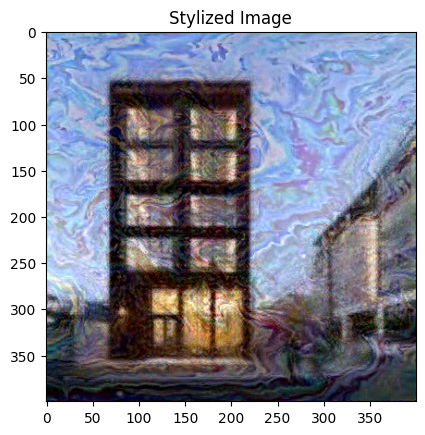

In [9]:
imshow(target, "Stylized Image")


In [10]:
from torchvision.utils import save_image

save_image(target, "stylized_output.jpg")
print("Image saved!")

Image saved!
